In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
import collections

ModuleNotFoundError: No module named 'pandas'

In [23]:
df = pd.read_csv('data/train.csv')
print("Dữ liệu đã tải xong:")
print(df.head())

NameError: name 'pd' is not defined

In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB


In [86]:
df.shape

(120000, 3)

In [87]:
df.rename(columns={'Class Index': 'label'}, inplace=True)

In [88]:
label_map = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

df['label'] = df['label'].map(label_map)

In [89]:
df = df.loc[:, ~df.columns.duplicated()]

In [90]:
print(df.columns)

Index(['label', 'Title', 'Description'], dtype='object')


In [91]:
df['label'].value_counts().sort_index()

label
Business    30000
Sci/Tech    30000
Sports      30000
World       30000
Name: count, dtype: int64

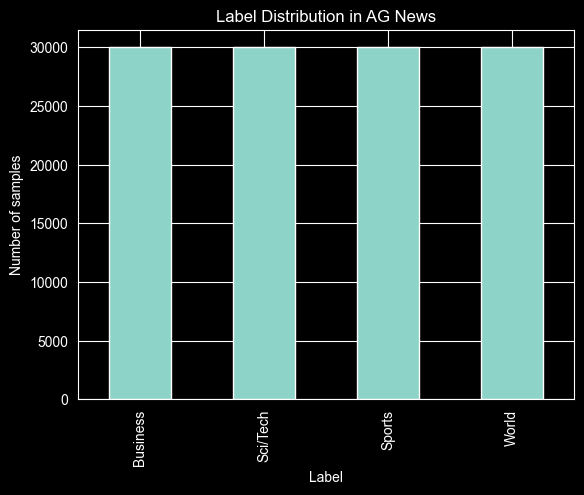

In [92]:
df['label'].value_counts().sort_index().plot(kind='bar')
plt.xlabel("Label")
plt.ylabel("Number of samples")
plt.title("Label Distribution in AG News")
plt.show()

In [93]:
print(df['label'].value_counts(normalize=True))

label
Business    0.25
Sci/Tech    0.25
Sports      0.25
World       0.25
Name: proportion, dtype: float64


In [94]:
df['text'] = df['Title'] + " " + df['Description']

In [95]:
def top_words(label, n=15):
    texts = df[df['label'] == label]['text']
    all_text = " ".join(texts).lower()
    words = re.findall(r'\b[a-z]+\b', all_text)
    counter = Counter(words)

    return counter.most_common(n)

In [96]:
for label in df['label'].unique():
    print(f"\n{label}:")
    print(top_words(label, 15))


Business:
[('the', 44820), ('to', 30221), ('a', 29097), ('of', 22781), ('in', 22300), ('and', 17190), ('on', 16780), ('s', 16660), ('for', 12165), ('its', 9567), ('reuters', 8717), ('as', 8299), ('that', 7345), ('said', 7311), ('new', 6632)]

Sci/Tech:
[('the', 48227), ('to', 31703), ('a', 27310), ('of', 26495), ('and', 18970), ('in', 17858), ('s', 13698), ('for', 12968), ('on', 12319), ('that', 9464), ('is', 7969), ('its', 7857), ('with', 7284), ('new', 7153), ('it', 6868)]

Sports:
[('the', 63383), ('to', 27672), ('a', 26115), ('in', 24050), ('of', 20390), ('and', 15853), ('s', 14389), ('for', 13903), ('on', 12353), ('at', 9358), ('with', 8409), ('his', 7851), ('ap', 6262), ('as', 5754), ('was', 5327)]

World:
[('the', 49038), ('in', 32216), ('to', 31138), ('a', 30819), ('of', 28981), ('and', 17655), ('s', 17237), ('on', 16208), ('for', 11638), ('said', 7745), ('that', 6805), ('at', 6271), ('as', 6232), ('with', 6064), ('iraq', 5837)]


In [97]:
df['char_length'] = df['text'].apply(len)
df['char_length'].describe()

count    120000.000000
mean        236.460025
std          66.529799
min          17.000000
25%         196.000000
50%         232.000000
75%         266.000000
max        1012.000000
Name: char_length, dtype: float64

In [98]:
df['word_length'] = df['text'].apply(lambda x: len(x.split()))
df['word_length'].describe()

count    120000.000000
mean         37.844617
std          10.088702
min           4.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: word_length, dtype: float64

$$\text{Ngưỡng trên} = Q3 + 1.5 \times IQR = 43 + (1.5 \times 11) = 43 + 16.5 = \mathbf{59.5}$$$$\text{Ngưỡng dưới} = Q1 - 1.5 \times IQR = 32 - (1.5 \times 11) = 32 - 16.5 = \mathbf{15.5}$$

In [99]:
Q1 = df['word_length'].quantile(0.25)
Q3 = df['word_length'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['word_length'] < Q1 - 1.5*IQR) | (df['word_length'] > Q3 + 1.5*IQR)]
print(f"Outliers: {len(outliers)} rows")

Outliers: 3577 rows


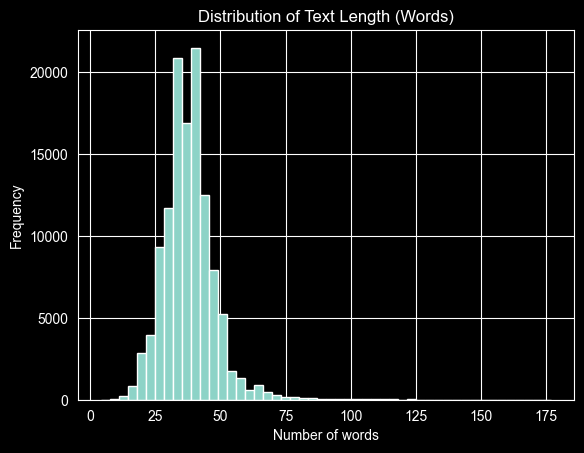

In [100]:
df['word_length'].hist(bins=50)
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.title("Distribution of Text Length (Words)")
plt.show()


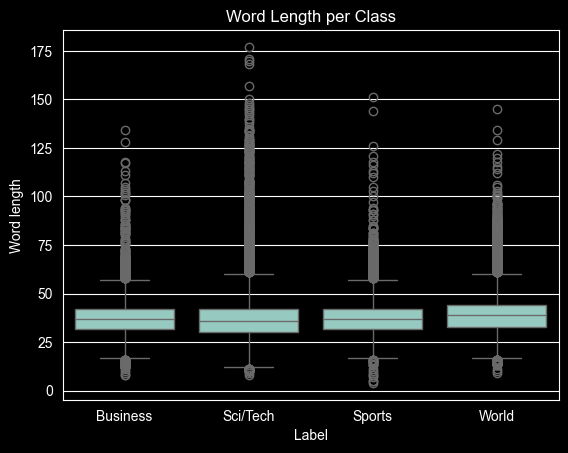

In [101]:
sns.boxplot(x='label', y='word_length', data=df)
plt.xlabel("Label")
plt.ylabel("Word length")
plt.title("Word Length per Class")
plt.show()


check noise

In [102]:
df[['Title', 'Description']].isnull().sum()

Title          0
Description    0
dtype: int64

In [103]:
(df['Title'].str.strip() == "").sum(), (df['Description'].str.strip() == "").sum()

(np.int64(0), np.int64(0))

In [104]:
def contains_special_char(text):
    return bool(re.search(r"[^a-zA-Z0-9\s.,']", text))

df['has_special_char'] = df['text'].apply(contains_special_char)
df['has_special_char'].mean()

np.float64(0.831075)

In [105]:
def contains_emoji(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F700-\U0001F77F"
        "]+", flags=re.UNICODE)
    return bool(emoji_pattern.search(text))

df['has_emoji'] = df['text'].apply(contains_emoji)
df['has_emoji'].sum()

np.int64(0)

In [106]:
print(df.groupby('label')['has_special_char'].mean())

label
Business    0.844433
Sci/Tech    0.817333
Sports      0.856767
World       0.805767
Name: has_special_char, dtype: float64


In [107]:
dirty_text = df[df['has_special_char'] == True]['text']
all_chars = "".join(dirty_text)

whitelist = set("abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789 .,'\n")
dirty_chars = [c for c in all_chars if c not in whitelist]

print(collections.Counter(dirty_chars).most_common(20))

[('-', 139159), (';', 87360), ('#', 47307), ('(', 41089), (')', 40770), ('\\', 26977), ('&', 26323), (':', 21517), ('/', 20990), ('"', 13035), ('$', 10976), ('=', 8440), ('?', 5723), ('!', 846), ('_', 198), ('*', 152)]


In [108]:
df['text'].duplicated().sum()


np.int64(0)

In [109]:
df[['text', 'label']].to_csv("agnews_clean.csv", index=False)
